In [1]:
import pandas as pd
import lightgbm as lgb
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

/home/rigonzal/miniconda3/envs/genv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib
matplotlib.__version__

'3.8.4'

In [3]:
shap.__version__

'0.46.0'

# 0.Config

In [4]:
path_fe = "../../outputs/fe/"

# 1. Data

In [5]:
df_mdt = pd.read_parquet(f"{path_fe}all_joined_fe_delta_years=3.parquet")
df_mdt.shape

(509352, 66)

# 2. Processing

In [6]:
# Create binary target
df_mdt["target"] = (df_mdt["arrdelay"] >= 15).astype(int)
df_mdt = df_mdt.drop(["arrdelay"], axis=1)
df_mdt["target"].mean()

np.float64(0.1828676435942138)

In [7]:
# 🔹 Define features and target
X = df_mdt.drop(columns=["unique_key", "month","target"])
y = df_mdt["target"]

In [8]:
# 🔹 Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train

,day,crsdeptime,avg_delay_route_last_30d,avg_delay_airline_dest_last_14d,rank,air_safety__general_aviation_fatalities,us_airline_traffic__total__seasonally_adjusted,us_airline_traffic__international__seasonally_adjusted,us_airline_traffic__domestic__seasonally_adjusted,state_and_local_government_construction_spending__conservation_and_development,...,originstate_NY,deststate_FL,deststate_NJ,deststate_NY,operating_airline_9E,operating_airline_AA,operating_airline_B6,operating_airline_DL,operating_airline_UA,operating_airline_YX
43976,27,1731,1.740385,-9.264706,15.0,33.0,54910000.0,4690000.0,50220000.0,253000000.0,...,1,0,0,0,0,0,1,0,0,0
391454,18,1257,-5.444444,-9.401460,28.0,25.0,68980000.0,6910000.0,62060000.0,276000000.0,...,1,0,0,0,1,0,0,0,0,0
224930,17,1109,1.101990,2.995465,19.0,25.0,68980000.0,6910000.0,62060000.0,276000000.0,...,0,0,0,1,0,0,1,0,0,0
295360,26,800,-0.562500,-6.000000,15.0,20.0,62000000.0,5460000.0,56550000.0,291000000.0,...,1,0,0,0,0,0,1,0,0,0
229961,25,2055,13.151515,16.250000,30.0,51.0,64690000.0,5690000.0,59000000.0,304000000.0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4,2120,9.191693,5.610954,20.0,33.0,54910000.0,4690000.0,50220000.0,253000000.0,...,0,0,0,1,0,0,1,0,0,0
365838,27,747,-15.436548,-14.020690,30.0,18.0,31590000.0,3280000.0,28300000.0,258000000.0,...,0,0,0,0,0,1,0,0,0,0
131932,26,1900,0.244000,15.925532,NaN,51.0,64690000.0,5690000.0,59000000.0,304000000.0,...,0,0,0,1,0,0,0,0,0,0
146867,5,600,-9.959288,-8.360000,28.0,25.0,68980000.0,6910000.0,62060000.0,276000000.0,...,1,0,0,0,0,0,0,0,1,0


# 3. Train

In [19]:

# 🔹 Train LightGBM Model
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "verbosity": -1,
    "random_state": 42
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

model = lgb.train(params, train_data, valid_sets=[val_data], num_boost_round=100,)

# 4. Metrics

In [20]:
# 🔹 Predictions & Metrics
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# Convert probabilities to binary (threshold = 0.5)
y_train_pred_bin = (y_train_pred >= 0.5).astype(int)
y_val_pred_bin = (y_val_pred >= 0.5).astype(int)

# 🔹 Compute Metrics
train_auc = roc_auc_score(y_train, y_train_pred)
val_auc = roc_auc_score(y_val, y_val_pred)

train_acc = accuracy_score(y_train, y_train_pred_bin)
val_acc = accuracy_score(y_val, y_val_pred_bin)

print(f"🔹 Train AUC: {train_auc:.3f} | Train Accuracy: {train_acc:.3f}")
print(f"🔹 Val AUC: {val_auc:.3f} | Val Accuracy: {val_acc:.3f}")
print("\n🔹 Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_bin))

🔹 Train AUC: 0.758 | Train Accuracy: 0.832
🔹 Val AUC: 0.749 | Val Accuracy: 0.830

🔹 Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.84      0.98      0.90     83195
           1       0.67      0.14      0.24     18676

    accuracy                           0.83    101871
   macro avg       0.75      0.56      0.57    101871
weighted avg       0.81      0.83      0.78    101871



# Feature importance SHAPs analysis

In [21]:
explainer = shap.Explainer(model)
shap_values = explainer(X_val)

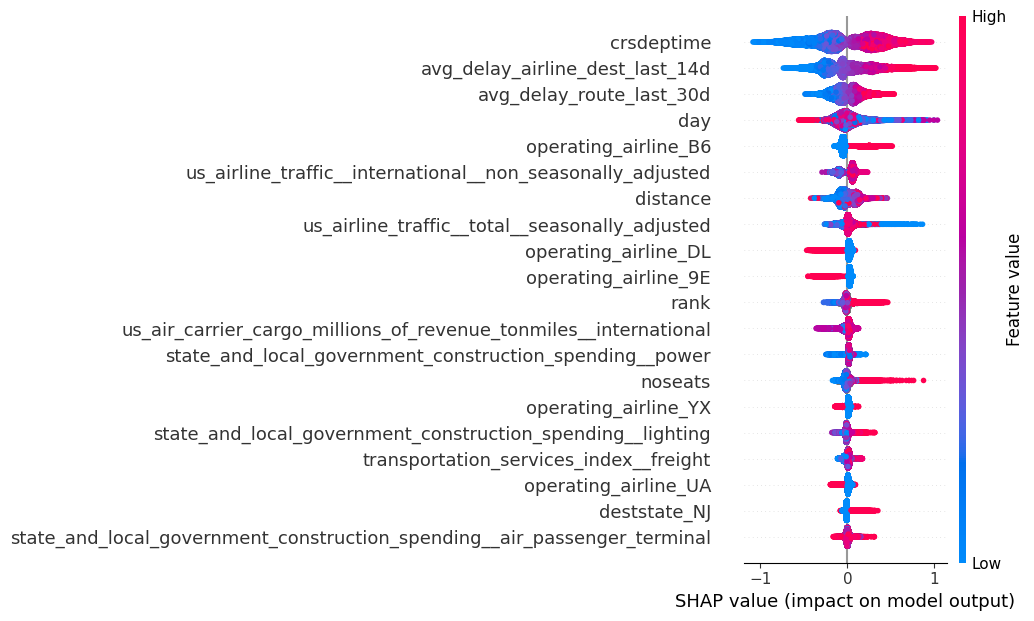

In [22]:
# 🔹 SHAP Summary Plot
#plt.figure(figsize=(18, 6))
fig = shap.summary_plot(shap_values, X_val, show=False)
w, h = plt.gcf().get_size_inches()
plt.gcf().set_size_inches(w*7, w*0.75)
plt.show()

#print(f'Original size: {plt.gcf().get_size_inches()}')
#w, _ = plt.gcf().get_size_inches()
#plt.gcf().set_size_inches(w, w*3/4)
#plt.tight_layout()
#print(f'New size: {plt.gcf().get_size_inches()}')


In [ ]:
# 🔹 SHAP Dependence Plot for Top Feature
top_feature = X_val.columns[np.argmax(np.abs(shap_values.values).mean(axis=0))]
shap.dependence_plot(top_feature, shap_values.values, X_val)

plt.show()